In [35]:
from numba import cuda
import matplotlib.pyplot as plt
import numpy as np
import time
import cv2

In [36]:
hostSrc = plt.imread('./green-lake-small.jpg')

In [37]:
H, W, _ = hostSrc.shape
C = 3
R, G, B = 1/3, 1/3, 1/3

In [38]:
print(f"Height: {H}")
print(f"Width: {W}")

Height: 550
Width: 900


In [39]:
flatSrc = hostSrc.reshape((H * W, C))

Execution time: 8.965s


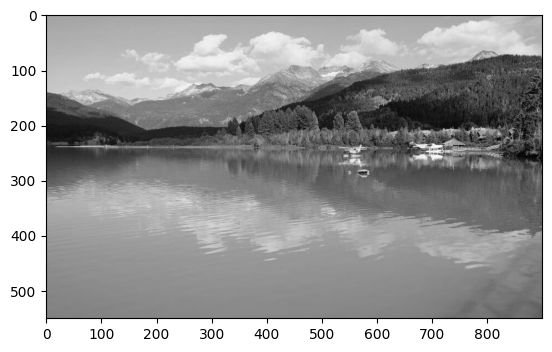

In [24]:
def cpu_grayscale(src, dst):
  for x in range(src.shape[0]):
    g = np.uint8(src[x, 0] * R + src[x, 1] * B + src[x, 2] * G)
    dst[x, 0] = dst[x, 1] = dst[x, 2] = g

start_time = time.time()

flatDst = np.zeros((H * W, C), np.uint8)
cpu_grayscale(flatSrc, flatDst)

end_time = time.time()

print(f'Execution time: {end_time - start_time:.3f}s')
plt.imshow(flatDst.reshape(H, W, C))

Execution time: 0.099s


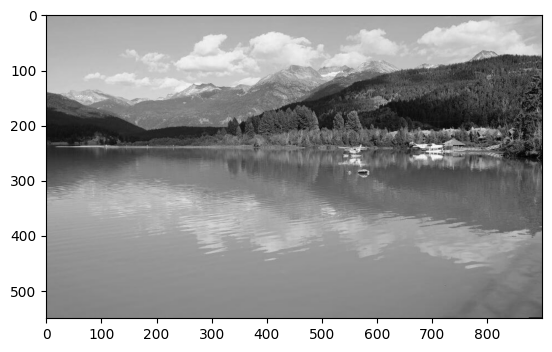

In [45]:
@cuda.jit
def gpu_grayscale(src, dst):
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g


blockSize = 64
gridSize = (H * W) // blockSize

start_time = time.time()

devSrc = cuda.to_device(flatSrc)
devDst = cuda.device_array((H * W, C), np.uint8)

gpu_grayscale[gridSize, blockSize](devSrc, devDst)

flatDst = devDst.copy_to_host()

end_time = time.time()

print(f'Execution time: {end_time - start_time:.3f}s')
plt.imshow(flatDst.reshape(H, W, C))

del devSrc, devDst, flatDst

## Varied Block Sizes Experiment

In [26]:
hostSrc.shape

(550, 900, 3)

In [27]:
SCALE = 10
bigH = H * SCALE
bigW = W * SCALE
bigSrc = cv2.resize(hostSrc, (bigH, bigW))
flatSrc = bigSrc.reshape((bigH * bigW, C))

In [28]:
bigSrc.shape

(9000, 5500, 3)

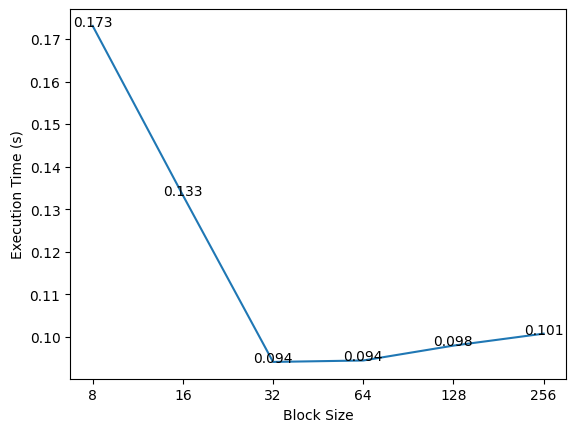

In [30]:
def timeByBlockSize(blockSize, repeat=5):
  gridSize = (bigH * bigW) // blockSize

  exeTimes = []
  for i in range(repeat):
    start_time = time.time()

    devSrc = cuda.to_device(flatSrc)
    devDst = cuda.device_array((bigH * bigW, C), np.uint8)

    gpu_grayscale[gridSize, blockSize](devSrc, devDst)

    flatDst = devDst.copy_to_host()

    end_time = time.time()
    del devSrc, devDst, flatDst

    exeTimes.append(end_time - start_time)

  return sum(exeTimes) / len(exeTimes)


power2s = list(range(3, 9))
blockSizes = [2**x for x in power2s]
exeTimes = [timeByBlockSize(x, 20) for x in blockSizes]

blockTicks = power2s
plt.plot(blockTicks, exeTimes)
plt.xticks(blockTicks, blockSizes)

plt.ylabel('Execution Time (s)')
plt.xlabel('Block Size')

for i, v in zip(blockTicks, exeTimes):
    plt.text(i, v, f"{v:.3f}", ha="center")
plt.show()